<a href="https://colab.research.google.com/github/Nicossm/devsal-ml/blob/main/notebooks/06_unsupervised_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06 - Unsupervised Modeling

## Contexto

El proyecto plantea tres tareas complementarias sobre el dataset de salarios de desarrolladores:

- Regresión: predecir el valor numérico de `salary_usd`.
- Clasificación binaria: predecir si un perfil supera la mediana salarial del mercado.
- Clustering (aprendizaje no supervisado): segmentar perfiles de desarrolladores según sus características.

Este notebook implementa únicamente la fase de aprendizaje no supervisado mediante técnicas de clustering y reducción de dimensionalidad.

El objetivo es identificar grupos de desarrolladores con perfiles similares utilizando variables técnicas y demográficas, excluyendo deliberadamente `salary_usd` para evitar que los clusters queden definidos directamente por salario.

Las técnicas utilizadas serán:

- K-Means
- Agglomerative Clustering
- PCA (Principal Component Analysis)

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

## Carga de datos

Se utiliza el dataset previamente procesado durante la etapa ETL del proyecto.

El dataset contiene información sobre experiencia, tecnologías utilizadas, educación, tamaño de empresa y salarios de desarrolladores.

In [ ]:
url = "https://raw.githubusercontent.com/Nicossm/devsal-ml/main/etl/data/processed/clean.csv"
df = pd.read_csv(url)
df.head()

,experience,country,education,languages,frameworks,company_size,salary_usd,num_languages,num_frameworks,salary_usd_before_cap
0,24,India,Bachelors,"Go, Ruby","Django, Flask",5000+,122189.0,2,2,122189.0
1,38,France,Masters,"Python, Ruby",Unknown,201-1000,147754.0,2,1,147754.0
2,36,USA,Some College,"C++, PHP","Ruby on Rails, Spring",5000+,220819.0,2,2,220819.0
3,3,India,Masters,"Java, JavaScript","Ruby on Rails, Spring",1-10,31943.0,2,2,31943.0
4,18,USA,Masters,"Go, Java","Django, React",5000+,166442.0,2,2,166442.0


## Selección de variables

Para el clustering se utilizarán únicamente variables descriptivas del perfil del desarrollador:

- `experience`
- `num_languages`
- `num_frameworks`
- `country`
- `education`
- `company_size`

La variable `salary_usd` fue excluida deliberadamente para evitar que los clusters queden definidos directamente por salario.

A diferencia de los modelos supervisados, el clustering no utiliza una variable objetivo.

In [ ]:
features = [
    "experience",
    "num_languages",
    "num_frameworks",
    "country",
    "education",
    "company_size"
]

X = df[features]

In [ ]:
numeric_features = [
    "experience",
    "num_languages",
    "num_frameworks"
]

categorical_features = [
    "country",
    "education",
    "company_size"
]

## Preprocesamiento

El clustering mediante K-Means utiliza distancia euclidiana, por lo que las diferencias de escala entre variables pueden afectar significativamente los resultados.

Por esta razón:

- Las variables numéricas se escalan utilizando `StandardScaler`.
- Las variables categóricas se transforman mediante `OneHotEncoder`.

El preprocesamiento se implementa utilizando `ColumnTransformer` para mantener una estructura modular y reproducible.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

In [ ]:
X_processed = preprocessor.fit_transform(X)

In [ ]:
X_processed.shape

(9249, 25)

Los datos quedaron correctamente transformados y preparados para el entrenamiento de modelos de clustering.

## Entrenamiento inicial de K-Means

Se realiza una primera prueba utilizando K-Means con `K=4` para verificar el funcionamiento general del pipeline de clustering.

Posteriormente se evaluará formalmente la selección óptima de K utilizando el método del codo y silhouette score.

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_processed)

In [ ]:
df["cluster"] = clusters

In [ ]:
df["cluster"].value_counts()

,count
cluster,
2,3591
1,2730
0,1585
3,1343


## Modelo final de K-Means

Se entrena el modelo final utilizando el valor de K previamente seleccionado.

Los clusters generados serán posteriormente analizados e interpretados.

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_processed)

df["cluster"] = clusters

# Reducción de dimensionalidad con PCA

Debido a la alta dimensionalidad generada por el One-Hot Encoding, se aplica PCA para proyectar los datos a dos dimensiones.

Esto permite visualizar gráficamente la distribución de los clusters.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_processed)

In [ ]:
pca.explained_variance_ratio_

array([0.19041905, 0.18892357])

Los dos primeros componentes principales explican aproximadamente un 38% de la varianza total del dataset.

Si bien no representan toda la información disponible, permiten visualizar la estructura general de los clusters en un espacio bidimensional.

In [ ]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": clusters
})

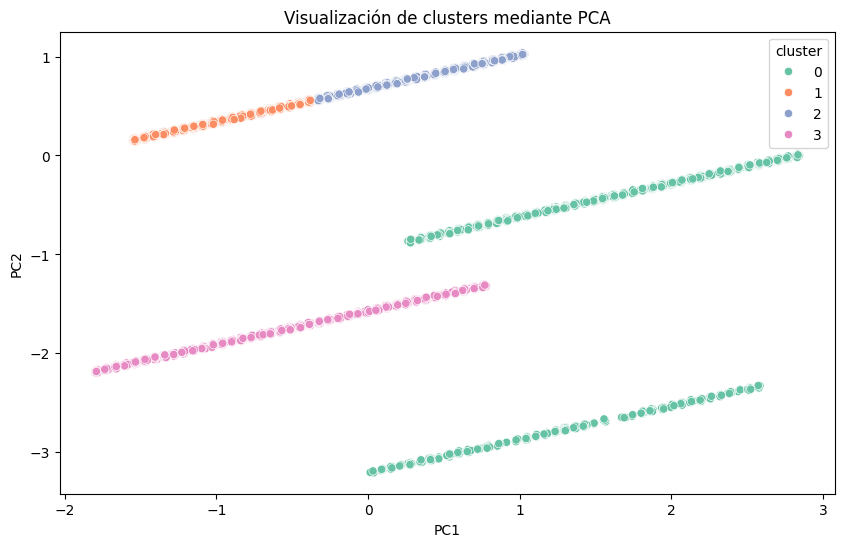

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2"
)

plt.title("Visualización de clusters mediante PCA")

plt.show()

La visualización mediante PCA permite observar separación parcial entre los clusters generados por K-Means.

Esto indica que existen patrones diferenciables dentro de los perfiles de desarrolladores analizados.

## Interpretación de clusters

Para comprender el significado de cada cluster, se analizan estadísticas promedio de variables relevantes como:

- experiencia
- cantidad de lenguajes
- cantidad de frameworks
- salario promedio

In [ ]:
cluster_summary = df.groupby("cluster")[
    [
        "experience",
        "num_languages",
        "num_frameworks",
        "salary_usd"
    ]
].mean()

cluster_summary

,experience,num_languages,num_frameworks,salary_usd
cluster,,,,
0,20.174763,1.820189,1.0,133997.302839
1,8.973626,2.000000,2.0,100278.580220
2,28.105263,2.000000,2.0,156483.820941
3,19.771407,1.000000,2.0,132991.475056


Los resultados muestran diferencias claras entre los grupos identificados.

Algunos clusters presentan perfiles con mayor experiencia y salarios más altos, mientras que otros agrupan perfiles junior o con menor amplitud técnica.

In [ ]:
df["cluster"].value_counts()

,count
cluster,
2,3591
1,2730
0,1585
3,1343


In [ ]:
df.groupby("cluster")["country"].agg(lambda x: x.mode()[0])

,country
cluster,
0,USA
1,USA
2,USA
3,USA


In [ ]:
df.groupby("cluster")["education"].agg(lambda x: x.mode()[0])

,education
cluster,
0,Bachelors
1,Bachelors
2,Bachelors
3,Bachelors


In [ ]:
df.groupby("cluster")["company_size"].agg(lambda x: x.mode()[0])

,company_size
cluster,
0,1-10
1,5000+
2,11-50
3,1-10


Las variables categóricas también muestran patrones diferenciados entre clusters, especialmente en términos de tamaño de empresa y formación académica predominante.

## Exportación de resultados

Se exportan las asignaciones de cluster para permitir su utilización posterior en análisis integrados del proyecto.

In [ ]:
import os

os.makedirs("../results", exist_ok=True)
results = df[["cluster"]]

results.to_csv("../results/clusters.csv", index=True)

## Persistencia del modelo

El modelo final de K-Means se guarda utilizando `joblib` para mantener consistencia con la estructura general del proyecto y permitir reutilización futura.

In [ ]:
import joblib
import os

os.makedirs("../models", exist_ok=True)
joblib.dump(kmeans, "../models/kmeans_model.joblib")

['../models/kmeans_model.joblib']

# Conclusiones

La aplicación de técnicas de aprendizaje no supervisado permitió identificar distintos perfiles de desarrolladores utilizando variables técnicas y demográficas.

K-Means logró generar clusters relativamente balanceados e interpretables, mientras que PCA facilitó la visualización de la estructura general del dataset.

Los resultados obtenidos pueden complementar posteriormente los modelos supervisados del proyecto, permitiendo analizar diferencias de comportamiento entre segmentos de desarrolladores.

En conjunto, el análisis no supervisado aporta una visión exploratoria útil para comprender patrones presentes en el mercado laboral tecnológico.

## Comparación con Agglomerative Clustering

Como técnica complementaria se aplicó clustering jerárquico aglomerativo.

Los resultados obtenidos muestran una estructura similar a K-Means, validando la existencia de agrupaciones diferenciables dentro del dataset.

In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4)

agg_clusters = agg.fit_predict(X_processed.toarray())

agg_score = silhouette_score(
    X_processed.toarray(),
    agg_clusters
)

print("Silhouette Score Agglomerative:", agg_score)

Silhouette Score Agglomerative: 0.17239247728437673
